In [28]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Bijay\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [29]:
import os
import pandas as pd

os.listdir(path)

df = pd.read_csv(os.path.join(path, 'creditcard.csv'))

print(df.shape)
print(df.head())
print(df["Class"].value_counts(normalize=True))

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [31]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [32]:
# print(df.duplicated().sum())
print(df[df.duplicated()]["Class"].value_counts())
df = df.drop_duplicates()
print(df.shape)
print(df.duplicated().sum())

Class
0    1062
1      19
Name: count, dtype: int64
(283726, 31)
0


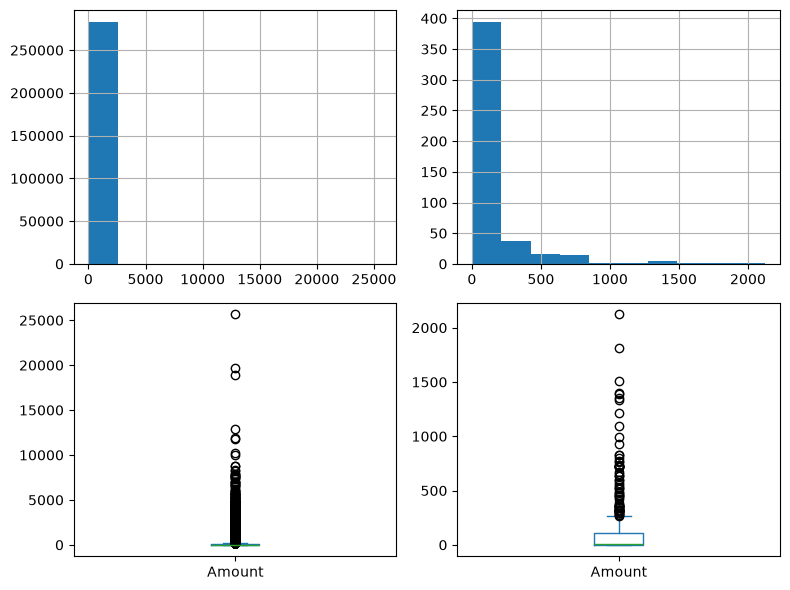

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

df[df.Class == 0]["Amount"].hist(ax=axes[0, 0])
df[df.Class == 1]["Amount"].hist(ax=axes[0, 1])

df[df.Class == 0]["Amount"].plot(kind="box", ax=axes[1, 0])
df[df.Class == 1]["Amount"].plot(kind="box", ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [38]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


### Conclusion of EDA

- Class heavily imbalanced with 0.17% as the fraud.
- Has v1-v28 which by the creator were given after PCA and stuff.
- Removed the duplicates.
- From the hist and boxplot, there are outliers higher for class 0.
- Skewed boxplot towards the lower bound.
- Fraud's mean-median gap is larger around 12x compare to non-fraud's 4x/
- Time is a float right now

In [45]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

In [56]:
df["hours"] = (df["Time"] % 86400) / 3600
df["hours"].describe()

count    283726.000000
mean         14.537139
std           5.846094
min           0.000000
25%          10.597500
50%          15.008889
75%          19.329167
max          23.999444
Name: hours, dtype: float64

In [59]:
df["hours"]

0          0.000000
1          0.000000
2          0.000278
3          0.000278
4          0.000556
            ...    
284802    23.996111
284803    23.996389
284804    23.996667
284805    23.996667
284806    23.997778
Name: hours, Length: 283726, dtype: float64

In [58]:
df.groupby(df["hours"].astype(int))["Class"].mean()

hours
0     0.000785
1     0.002376
2     0.014510
3     0.004875
4     0.010436
5     0.003681
6     0.002205
7     0.003180
8     0.000880
9     0.001015
10    0.000483
11    0.003158
12    0.001105
13    0.001109
14    0.001392
15    0.001588
16    0.001342
17    0.001736
18    0.001651
19    0.001221
20    0.001078
21    0.000908
22    0.000585
23    0.001562
Name: Class, dtype: float64

In [60]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'hours'],
      dtype='str')

In [61]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

scale = RobustScaler()

X = df.drop(columns=['Time', 'Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

X_train["Amount"] = scale.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scale.transform(X_test[["Amount"]])

In [62]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

def train_model(model, X_train, X_test, y_train, y_test, probability=0.3):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba > probability).astype(int)

    print(f"Confusion report:\n {confusion_matrix(y_test, pred)}\n")
    print(f"Classification report:\n {classification_report(y_test, pred)}")

    precision, recall, threshold = precision_recall_curve(y_test, proba)
    plt.plot(threshold, precision[:-1], label="precision")
    plt.plot(threshold, recall[:-1], label="recall")
    plt.legend()
    plt.show()

In [69]:
train_model(
    RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight="balanced"
    ),
    X_train, X_test, y_train, y_test
)

Confusion report:
 [[56644     7]
 [   21    74]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.78      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



Confusion report:
 [[56195   456]
 [   21    74]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.14      0.78      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.89      0.62     56746
weighted avg       1.00      0.99      0.99     56746



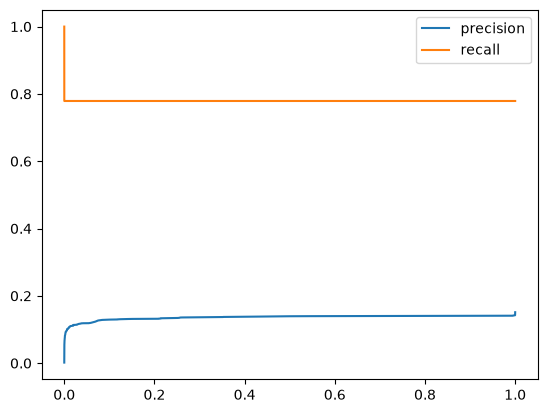

In [77]:
from lightgbm import LGBMClassifier
import math

scale_pos_weight = math.sqrt((y == 0).sum() / (y == 1).sum())

train_model(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight),
    X_train, X_test, y_train, y_test, probability=0.5
)

In [78]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", random_state=42
    ),
    param_distributions=param_grid,
    n_iter=10,
    cv=skf,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Randomized

In [81]:
print(search.best_params_)
print(search.best_score_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
0.8307017543859649


Confusion report:
 [[56631    20]
 [   23    72]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.76      0.77        95

    accuracy                           1.00     56746
   macro avg       0.89      0.88      0.88     56746
weighted avg       1.00      1.00      1.00     56746



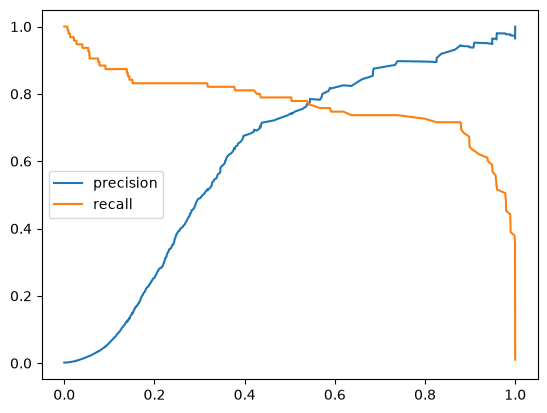

In [83]:
train_model(
    RandomForestClassifier(
        n_estimators=100, min_samples_split=2, min_samples_leaf=4,
        max_depth=10, random_state=42, class_weight="balanced"
    ),
    X_train, X_test, y_train, y_test, probability=0.55
)